In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from mnn_torch import paths
from mnn_torch.training import (
    gate_homeostasis_sweep,
    dose_response,
    isolate_collapse,
    precompute_device_params,
)
from mnn_torch.data import ensure_mnist

# Default mode computes reduced-budget live data. Set to "full_sweep_cache" only
# to render committed outputs from heavier command-line sweeps.
RESULT_MODE = "live"
if RESULT_MODE not in {"live", "full_sweep_cache"}:
    raise ValueError("RESULT_MODE must be 'live' or 'full_sweep_cache'")

LIVE_SEEDS = (0,)
LIVE_PROBS = (0.0, 0.2, 0.4)
LIVE_RATES = (0.0, 0.2, 0.4)
LIVE_TRAIN_SUBSET = 512
LIVE_TEST_SUBSET = 512
LIVE_EPOCHS = 1
LIVE_NUM_STEPS = 5
LIVE_DEVICE = "cuda"  # change to "cpu" if CUDA is unavailable

TEAL, RED, BLUE, GREY, AMBER = "#3aa07a", "#c0392b", "#2f4b8f", "#9aa6b2", "#e0a93b"
INK = "#2b2b2b"


def _clean(ax):
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.set_axisbelow(True); ax.grid(True, color="0.88", lw=0.5)


def _have(name):
    return (paths.results_dir() / name).exists()


print("RESULT_MODE:", RESULT_MODE)
print("data/results:", paths.results_dir())

RESULT_MODE: live
data/results: C:\Users\User\git\mnn-torch\data\results


### Homeostatic fault-recovery sweep

`RESULT_MODE = "live"` runs a reduced-budget version of the same training code used by the command-line sweeps. `RESULT_MODE = "full_sweep_cache"` renders committed multi-seed outputs and prints their provenance. The full commands are left commented in the final cell for examiners who want to regenerate those caches.

LIVE reduced run: seeds=(0,), train_subset=512, epochs=1


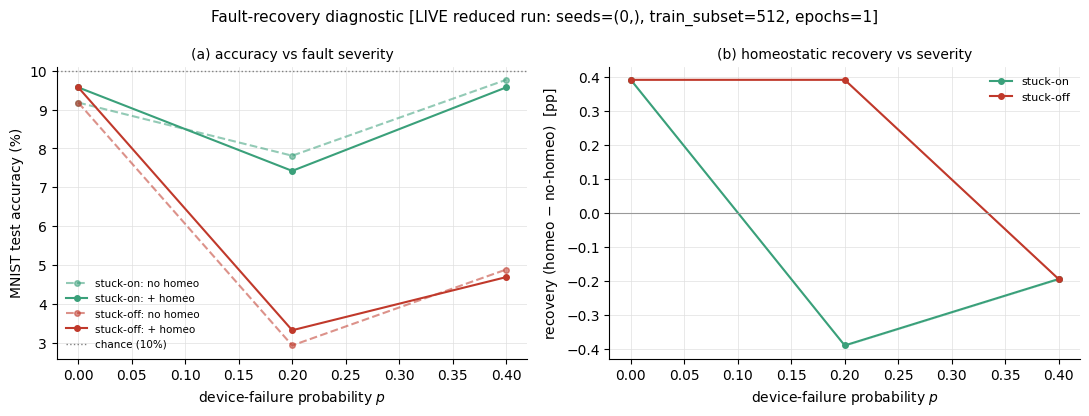

In [2]:
if RESULT_MODE == "live":
    ensure_mnist()
    dev_params = precompute_device_params()
    grid = gate_homeostasis_sweep(
        dev_params=dev_params, seeds=LIVE_SEEDS, probs=LIVE_PROBS,
        polarities=("on", "off"), disturb_mode="device_fixed",
        epochs=LIVE_EPOCHS, num_steps=LIVE_NUM_STEPS,
        train_subset=LIVE_TRAIN_SUBSET, test_subset=LIVE_TEST_SUBSET,
        device=LIVE_DEVICE, workers=1, verbose=False)
    src = f"LIVE reduced run: seeds={LIVE_SEEDS}, train_subset={LIVE_TRAIN_SUBSET}, epochs={LIVE_EPOCHS}"
elif _have("gate_sweep.npy"):
    grid = paths.load_result("gate_sweep.npy"); src = "FULL-SWEEP CACHE: gate_sweep.npy"
elif _have("gate_sweep_results.npy"):
    grid = paths.load_result("gate_sweep_results.npy"); src = "CACHE: gate_sweep_results.npy"
else:
    raise FileNotFoundError("No gate sweep cache found; use RESULT_MODE='live' or run python -m mnn_torch.training --gate --full")
print(src)

probs = np.asarray(grid["probs"], float)
pols = list(grid["polarities"])
acc = grid["acc"]
POL_COL = {"on": TEAL, "off": RED, "split": BLUE}
POL_LAB = {"on": "stuck-on", "off": "stuck-off", "split": "stuck split"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for pol in pols:
    col = POL_COL.get(pol, "#444")
    nh = np.asarray(acc[f"{pol}|no"], float).mean(0)
    h = np.asarray(acc[f"{pol}|homeo"], float).mean(0)
    ax1.plot(probs, nh, "--o", color=col, alpha=0.55, ms=4, label=f"{POL_LAB.get(pol, pol)}: no homeo")
    ax1.plot(probs, h, "-o", color=col, ms=4, label=f"{POL_LAB.get(pol, pol)}: + homeo")
    rec_g = np.asarray(acc[f"{pol}|homeo"], float) - np.asarray(acc[f"{pol}|no"], float)
    rec_m = rec_g.mean(0)
    cells = grid["summary"][pol]["cells"]
    lo = np.array([c["ci_lo"] for c in cells]); hi = np.array([c["ci_hi"] for c in cells])
    ax2.plot(probs, rec_m, "-o", color=col, ms=4, label=POL_LAB.get(pol, pol))
    ax2.fill_between(probs, lo, hi, color=col, alpha=0.15)
ax1.axhline(10.0, ls=":", lw=1, color="0.5", label="chance (10%)")
ax1.set_xlabel("device-failure probability $p$"); ax1.set_ylabel("MNIST test accuracy (%)")
ax1.set_title("(a) accuracy vs fault severity", fontsize=10)
ax1.legend(frameon=False, fontsize=7.5); _clean(ax1)
ax2.axhline(0.0, ls="-", lw=0.8, color="0.6")
ax2.set_xlabel("device-failure probability $p$")
ax2.set_ylabel(r"recovery (homeo $-$ no-homeo)  [pp]")
ax2.set_title("(b) homeostatic recovery vs severity", fontsize=10)
ax2.legend(frameon=False, fontsize=8); _clean(ax2)
fig.suptitle(f"Fault-recovery diagnostic [{src}]", fontsize=11)
fig.tight_layout(); plt.show()

LIVE reduced run: rates=(0.0, 0.2, 0.4), train_subset=512, epochs=1


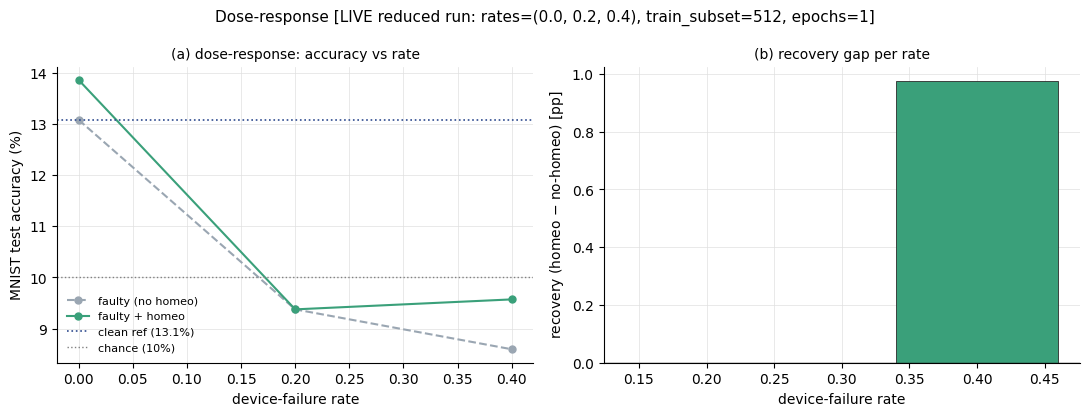

In [3]:
records = []
if RESULT_MODE == "live":
    ensure_mnist()
    dev_params = precompute_device_params()
    for rate in LIVE_RATES:
        records.append(dose_response(
            rate, dev_params=dev_params, seed=0, epochs=LIVE_EPOCHS,
            num_steps=LIVE_NUM_STEPS, train_subset=LIVE_TRAIN_SUBSET,
            test_subset=LIVE_TEST_SUBSET, device=LIVE_DEVICE, verbose=False))
    src = f"LIVE reduced run: rates={LIVE_RATES}, train_subset={LIVE_TRAIN_SUBSET}, epochs={LIVE_EPOCHS}"
else:
    dose_dir = paths.results_dir() / "dose"
    if not dose_dir.exists() or not any(dose_dir.glob("rate_*.json")):
        raise FileNotFoundError("No dose cache found; run python -m mnn_torch.training --dose --rate 0.2 --full")
    for fn in sorted(dose_dir.glob("rate_*.json")):
        records.append(json.load(open(fn)))
    src = f"FULL-SWEEP CACHE: {dose_dir}"
print(src)

records.sort(key=lambda r: r["rate"])
rates = np.array([r["rate"] for r in records], float)
ideal = next((r["ideal"] for r in records if r["rate"] == 0.0), np.nan)
faulty = np.array([r.get("faulty", r.get("ideal", np.nan)) for r in records], float)
faulty_h = np.array([r.get("faulty+homeo", r.get("ideal+homeo", np.nan)) for r in records], float)
rec = np.array([r.get("recovery", np.nan) for r in records], float)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11, 4.2))
axA.plot(rates, faulty, "--o", color=GREY, ms=5, label="faulty (no homeo)")
axA.plot(rates, faulty_h, "-o", color=TEAL, ms=5, label="faulty + homeo")
if np.isfinite(ideal):
    axA.axhline(ideal, ls=":", color=BLUE, lw=1.2, label=f"clean ref ({ideal:.1f}%)")
axA.axhline(10.0, ls=":", color="0.5", lw=1, label="chance (10%)")
axA.set_xlabel("device-failure rate"); axA.set_ylabel("MNIST test accuracy (%)")
axA.set_title("(a) dose-response: accuracy vs rate", fontsize=10)
axA.legend(frameon=False, fontsize=8); _clean(axA)
mfin = np.isfinite(rec)
axB.bar(rates[mfin], rec[mfin], width=max(0.03, 0.6 * np.diff(np.sort(rates)).min() if len(rates) > 1 else 0.06),
        color=[TEAL if v > 0 else GREY for v in rec[mfin]], edgecolor=INK, linewidth=0.6)
axB.axhline(0.0, color=INK, lw=1)
axB.set_xlabel("device-failure rate"); axB.set_ylabel("recovery (homeo $-$ no-homeo) [pp]")
axB.set_title("(b) recovery gap per rate", fontsize=10); _clean(axB)
fig.suptitle(f"Dose-response [{src}]", fontsize=11)
fig.tight_layout(); plt.show()

LIVE reduced run: train_subset=512, epochs=1


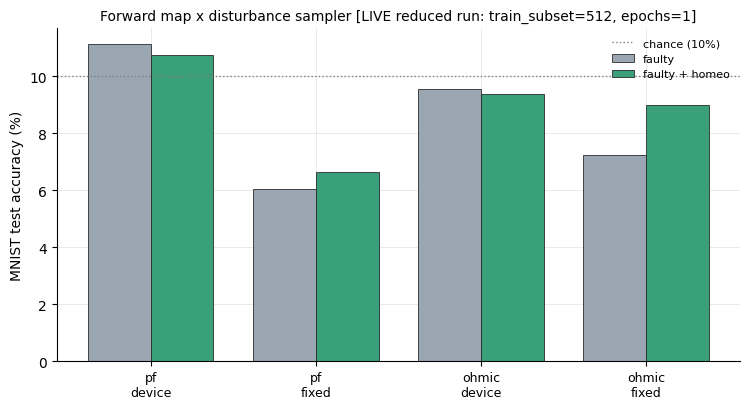

In [4]:
recs = []
if RESULT_MODE == "live":
    ensure_mnist()
    dev_params = precompute_device_params()
    for mp, mode in (("pf", "device"), ("pf", "fixed"), ("ohmic", "device"), ("ohmic", "fixed")):
        recs.append(isolate_collapse(
            mp, mode, dev_params=dev_params, rate=0.3, seed=0,
            epochs=LIVE_EPOCHS, num_steps=LIVE_NUM_STEPS,
            train_subset=LIVE_TRAIN_SUBSET, test_subset=LIVE_TEST_SUBSET,
            device=LIVE_DEVICE, verbose=False))
    src = f"LIVE reduced run: train_subset={LIVE_TRAIN_SUBSET}, epochs={LIVE_EPOCHS}"
else:
    iso_dir = paths.results_dir() / "isolate"
    if not iso_dir.exists() or not any(iso_dir.glob("*.json")):
        raise FileNotFoundError("No isolate cache found; run python -m mnn_torch.training --isolate --map pf --mode device --full")
    for fn in sorted(iso_dir.glob("*.json")):
        recs.append(json.load(open(fn)))
    src = f"FULL-SWEEP CACHE: {iso_dir}"
print(src)

labels = [f"{r['map']}\n{r['mode']}" for r in recs]
faulty = np.array([r["faulty"] for r in recs], float)
faulty_h = np.array([r["faulty+homeo"] for r in recs], float)
x = np.arange(len(recs)); w = 0.38
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(x - w / 2, faulty, w, color=GREY, edgecolor=INK, linewidth=0.6, label="faulty")
ax.bar(x + w / 2, faulty_h, w, color=TEAL, edgecolor=INK, linewidth=0.6, label="faulty + homeo")
ax.axhline(10.0, ls=":", color="0.5", lw=1, label="chance (10%)")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("MNIST test accuracy (%)")
ax.set_title(f"Forward map x disturbance sampler [{src}]", fontsize=10)
ax.legend(frameon=False, fontsize=8); _clean(ax)
fig.tight_layout(); plt.show()

In [5]:
# Full-cache regeneration commands, intentionally left commented for examiners:
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "mnn_torch.training", "--gate", "--full"])
# for rate in (0.0, 0.2, 0.4):
#     subprocess.run([sys.executable, "-m", "mnn_torch.training", "--dose", "--rate", str(rate), "--full"])
# for mp, mode in (("pf", "device"), ("pf", "fixed"), ("ohmic", "device"), ("ohmic", "fixed")):
#     subprocess.run([sys.executable, "-m", "mnn_torch.training", "--isolate", "--map", mp, "--mode", mode, "--full"])
print("homeostasis notebook complete")

homeostasis notebook complete
